In [157]:
import imageio
from skimage.morphology import dilation, remove_small_objects, area_closing, area_opening, erosion, disk
from skimage.filters import median, threshold_local, rank, threshold_otsu

In [2]:
img = imageio.imread('/localhome/asa420/MIAL/data/confocal-data/ATL/er_mean_proc/atl1_proc_skel.png')

In [3]:
import matplotlib.pyplot as plt

In [5]:
# p1 = img > 0
# p1 = remove_small_objects(p1, )
# p1 = dilation(img)
# # p1 = area_opening(img)
# p2 = erosion(p1)
m = median(img)

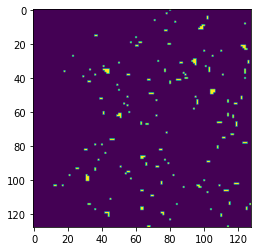

In [6]:
plt.imshow(m)

In [17]:
import numpy as np
from skimage.measure import label, regionprops
np.unique(label(m))
l = label(m)
props = regionprops(label(m))

In [25]:
print(np.unique(l))

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121]


In [28]:
len(props)

121

In [31]:
# d = []
# for i in range(1, len(props)):
#     if props[i]['Area'] == 1:
#         d.append(i)

In [44]:
# new = np.zeros((128,128))
# new[l[d]] = 255.
np.where(l[7]!=0)

(array([83]),)

In [36]:
# plt.imshow(new)

In [38]:
p3 = p2 > 0

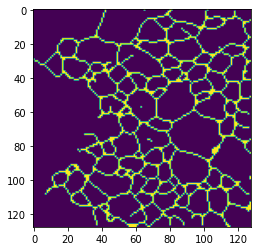

In [39]:
plt.imshow(p3)

In [5]:
dil = dilation(img)

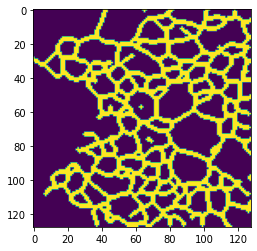

In [7]:
plt.imshow(dil)

In [46]:
# m = median(dil)
tl = threshold_local(dil, 3)

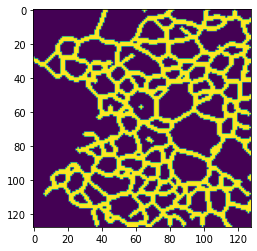

In [47]:
plt.imshow(tl)

In [47]:
groups = ['ATL', 'Climp', 'Control', 'RTN']


for group in groups:
    for i in range(1, 32):
        try:
            gt = imageio.imread(f'/localhome/asa420/MIAL/data/confocal-data/{group}/er_mean_proc/{group.lower()}{i}_proc_skel.png')
            mask = dilation(gt)
            imageio.imsave(f'/localhome/asa420/MIAL/data/confocal-data/masks/{group.lower()}{i}_mask.png', mask)
        except:
            pass

In [94]:
groups = ['ATL', 'Climp', 'Control', 'RTN']

import os
for group in groups:
    for i in range(1, 32):
        try:
            file = f'/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/{group.lower()}/masks/{group.lower()}{i}_proc_skel_mask.png'
            os.rename(file, f'/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/{group.lower()}/masks/{group.lower()}{i}_er_mean_mask.png')
        except:
            pass

In [95]:
import torch
import torch.nn as nn

class UNet(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(UNet, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Mid-level
        self.mid_level = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
#             nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, out_channels, kernel_size=2, stride=2, output_padding=0)  # Adjusted output_padding
        )

    def forward(self, x):
        # Encoder
        x1 = self.encoder(x)

        # Mid-level
        x2 = self.mid_level(x1)

        # Decoder
        x3 = self.decoder(x2)

        return x3

# Example usage:
in_channels = 1  # Assuming grayscale images
out_channels = 1  # Assuming binary segmentation output

# Adjust the model instantiation
model = UNet(in_channels, out_channels)


In [96]:
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class ERDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = os.listdir(root_dir)

    def __len__(self):
        return sum(len(os.listdir(os.path.join(self.root_dir, cls, 'images'))) for cls in self.classes)

    def __getitem__(self, idx):
        current_class_idx = 0
        while idx >= len(os.listdir(os.path.join(self.root_dir, self.classes[current_class_idx], 'images'))):
            idx -= len(os.listdir(os.path.join(self.root_dir, self.classes[current_class_idx], 'images')))
            current_class_idx += 1

        current_class = self.classes[current_class_idx]
        img_folder = os.path.join(self.root_dir, current_class, 'images')
        mask_folder = os.path.join(self.root_dir, current_class, 'masks')

        img_name = os.listdir(img_folder)[idx]
        img_path = os.path.join(img_folder, img_name)
        mask_name = os.path.splitext(img_name)[0] + '_mask.png'  # Assuming mask files have the same name as images with '_mask' appended
        mask_path = os.path.join(mask_folder, mask_name)

        image = Image.open(img_path)#.convert("RGB")
        mask = Image.open(mask_path)#.convert("L")  # Convert to grayscale mask

        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)

        return image, mask

# Define your transformation
transform = transforms.Compose([
#     transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

# Define your dataset
# root_dir = 'path/to/your/dataset'
root_dir = '/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/'

dataset = ERDataset(root_dir, transform=transform)

# Define your dataloader
# batch_size = 4
# data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)


In [97]:
data_loader

In [246]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms

# # Define your UNet model
# class UNet(nn.Module):
#     # ... (same as before)

# Initialize your UNet model
in_channels = 1  # Assuming RGB images
out_channels = 1  # Assuming binary segmentation
model = UNet(in_channels, out_channels)

# Define your loss function and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Define your dataset and dataloaders
# root_dir = 'path/to/your/dataset'
# transform = transforms.Compose([
#     transforms.Resize((256, 256)),
#     transforms.ToTensor(),
# ])

# dataset = CustomDataset(root_dir, transform=transform)

# Assuming an 80-20 train-test split
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

batch_size = 4
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Training loop
num_epochs = 50
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in range(num_epochs):
    model.train()
    for inputs, masks in train_loader:
        inputs, masks = inputs.to(device), masks.to(device)

        # Forward pass
        outputs = model(inputs)
#         outputs = (torch.sigmoid(outputs) > 0.5).float()
        loss = criterion(outputs, masks)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Print the training loss for each epoch
    print(f"Epoch [{epoch + 1}/{num_epochs}], Training Loss: {loss.item()}")

# Testing loop
model.eval()
test_loss = 0.0
with torch.no_grad():
    for inputs, masks in test_loader:
        inputs, masks = inputs.to(device), masks.to(device)

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, masks)
        test_loss += loss.item()

# Calculate and print the average test loss
average_test_loss = test_loss / len(test_loader)
print(f"Average Test Loss: {average_test_loss}")

# Save the trained model
torch.save(model.state_dict(), 'unet_model.pth')


/localhome/asa420/anaconda3/envs/as3/lib/python3.7/site-packages/ipykernel_launcher.py:13: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  del sys.path[0]


Epoch [1/50], Training Loss: 0.4313593804836273
Epoch [2/50], Training Loss: 0.3878079354763031
Epoch [3/50], Training Loss: 0.18517936766147614
Epoch [4/50], Training Loss: 0.14507414400577545
Epoch [5/50], Training Loss: 0.10995516926050186
Epoch [6/50], Training Loss: 0.06180289387702942
Epoch [7/50], Training Loss: 0.07776208966970444
Epoch [8/50], Training Loss: 0.15318679809570312
Epoch [9/50], Training Loss: 0.08357607573270798
Epoch [10/50], Training Loss: 0.07330022752285004
Epoch [11/50], Training Loss: 0.10848516970872879
Epoch [12/50], Training Loss: 0.16117417812347412
Epoch [13/50], Training Loss: 0.05011264979839325
Epoch [14/50], Training Loss: 0.06762716174125671
Epoch [15/50], Training Loss: 0.11209876835346222
Epoch [16/50], Training Loss: 0.08332781493663788
Epoch [17/50], Training Loss: 0.10766847431659698
Epoch [18/50], Training Loss: 0.10757917910814285
Epoch [19/50], Training Loss: 0.05967758223414421
Epoch [20/50], Training Loss: 0.1295546144247055
Epoch [21/50

In [85]:
len(dataset)

117

In [ ]:

def get_unet_skel():

    for seq in range(1, 27):
        for frame in range(100):
            image_path = f'/localhome/asa420/MIAL/data/confocal-data/ATL/std/A{seq}_decon_t0{frame:02d}_ch00_std.png'

            image = Image.open(image_path)
            transform = transforms.Compose([
            #     transforms.Resize((128, 128)),
                transforms.ToTensor(),
            ])

            image = transform(image)
            image = image.unsqueeze(0)  # Add batch dimension

            # Forward pass through the model
            model.eval()
            with torch.no_grad():
                output = model(image.to('cuda'))

            # Convert the output to probabilities by applying the sigmoid activation
            output_probs = torch.sigmoid(output)
            type(output_probs)

            # Convert tensors to numpy arrays for visualization
            image_np = image.squeeze().numpy()
            output_probs_np = output_probs.cpu().squeeze().numpy()

            norm = (output_probs_np - output_probs_np.min()) / (output_probs_np.max() - output_probs_np.min())
            norm_er = erosion(norm)
            rb = restoration.rolling_ball(norm)

            subt = norm_er - rb

            import copy
            subt2 = copy.deepcopy(subt)
            subt2[subt < 0.1] = 0.
            subt2[subt >= 0.1] = 255.

            from plantcv import plantcv as pcv
            skel = pcv.morphology.skeletonize(subt2)

            imageio.imsave(f'/localhome/asa420/MIAL/data/confocal-data/ATL/skel/A{seq}_decon_t0{frame:02d}_ch00_skel.png', skel)

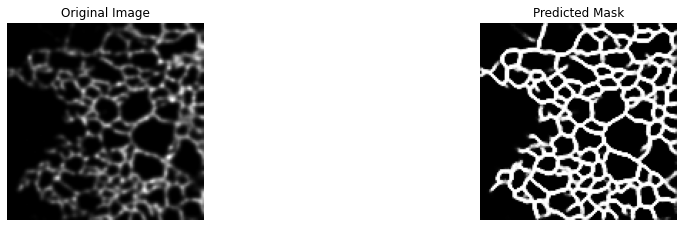

In [352]:
# Load a sample image (replace 'path/to/sample/image.jpg' with your actual image path)
# image_path = '/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/atl/images/atl4_er_mean.png'

image_path = '/localhome/asa420/MIAL/data/confocal-data/ATL/std/A1_decon_t043_ch00_std.png'
# mask = imageio.imread('/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/atl/masks/atl4_er_mean_mask.png')

image = Image.open(image_path)#.convert('L')  # Convert to grayscale
transform = transforms.Compose([
#     transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

image = transform(image)
image = image.unsqueeze(0)  # Add batch dimension

# Forward pass through the model
model.eval()
with torch.no_grad():
    output = model(image.to('cuda'))

# Convert the output to probabilities by applying the sigmoid activation
output_probs = torch.sigmoid(output)
type(output_probs)

# Convert tensors to numpy arrays for visualization
image_np = image.squeeze().numpy()
output_probs_np = output_probs.cpu().squeeze().numpy()

# Plot the original image, ground truth mask, and predicted mask
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image_np, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# plt.subplot(1, 3, 2)
# plt.imshow(mask, cmap='gray')
# plt.title('Mask')
# plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(output_probs_np, cmap='gray')
plt.title('Predicted Mask')
plt.axis('off')

plt.show()

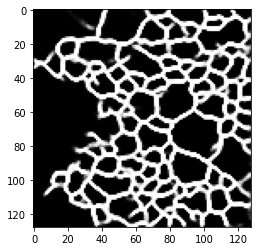

In [353]:
plt.imshow(output_probs_np, cmap='gray')

In [354]:
norm = (output_probs_np - output_probs_np.min()) / (output_probs_np.max() - output_probs_np.min())

In [355]:
# imageio.imsave('norm_tf.tif', norm)

In [356]:
norm_er = erosion(norm)

In [357]:
from skimage import restoration

In [358]:
rb = restoration.rolling_ball(norm)

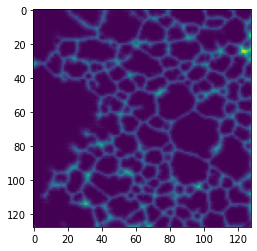

In [359]:
plt.imshow(rb)

In [360]:
rb.max()

0.109710105

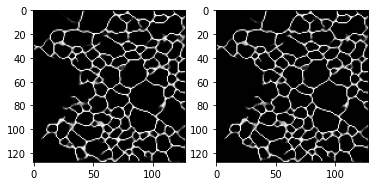

In [361]:
subt = norm_er - rb
plt.subplot(1,2,1)
plt.imshow(norm_er, cmap='gray')

plt.subplot(1,2,2)
plt.imshow(subt, cmap='gray')

In [362]:
subt.min()

-0.0050001256

In [363]:
subt.max()

0.98931456

In [364]:
# subt[subt <= rb.max()] = 0.
# subt[subt > rb.max()] = 255.

In [365]:
import copy
subt2 = copy.deepcopy(subt)
subt2[subt < 0.1] = 0.
subt2[subt >= 0.1] = 255.

In [366]:
np.unique(subt2)

array([  0., 255.], dtype=float32)

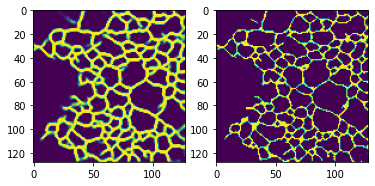

In [367]:
plt.subplot(121)
plt.imshow(norm)

plt.subplot(122)
plt.imshow(subt2)

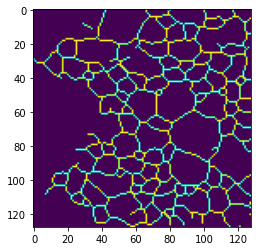

In [368]:
from plantcv import plantcv as pcv
skel = pcv.morphology.skeletonize(subt2)
plt.imshow(skel)

In [278]:
imageio.imsave('subt.png', subt)

Lossy conversion from float32 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.


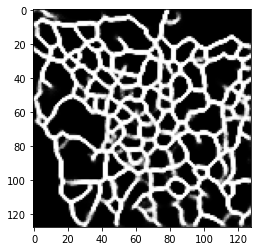

In [262]:
plt.imshow(norm, cmap='gray')

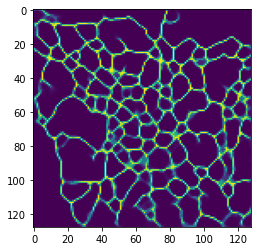

In [251]:
norm_er = erosion(norm)
plt.imshow(norm_er)

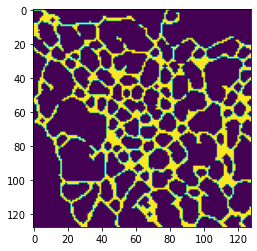

In [256]:
aop = area_opening(norm_er, area_threshold=2)
plt.imshow(aop)

In [255]:
imageio.imsave('rtn8_norm_er.png', norm_er)

Lossy conversion from float32 to uint8. Range [0.0, 255.0]. Convert image to uint8 prior to saving to suppress this warning.


In [252]:
# radius = 1
# selem = disk(radius)

from skimage.filters import threshold_mean, threshold_multiotsu, threshold_minimum

# local_otsu = rank.otsu(norm, selem)
# thr = threshold_otsu(norm)
# op = norm > thr
# thl = threshold_multiotsu(norm)
thl = threshold_local(norm_er, 3)
thl = thl.astype('float16')
# thval = np.mean(thl)

thmin = threshold_minimum(norm_er)

In [253]:
thmin

0.5096538

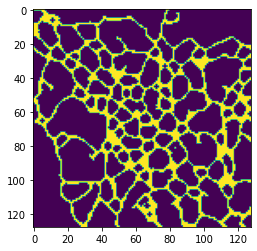

In [254]:
norm_er[norm_er > 0.05] = 255.
plt.imshow(norm_er)

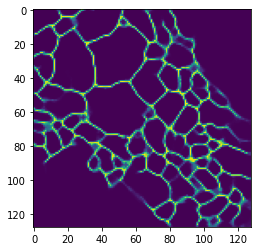

In [232]:
plt.imshow(thl)

In [233]:
np.unique(thl)

array([0.000e+00, 5.960e-08, 1.192e-07, ..., 9.824e-01, 9.829e-01,
       9.834e-01], dtype=float16)

In [240]:
# plt.imshow(thl)

In [215]:
norm_er.max()

0.9992901

In [216]:
norm_er.min()

0.0

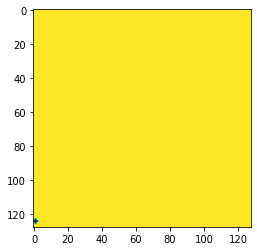

In [217]:
norm_er[norm_er > 0] = 255.
plt.imshow(norm_er)

In [207]:
norm[norm<=thl] = 0.
norm[norm>thl] = 255.

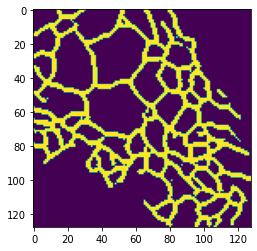

In [208]:
plt.imshow(norm)

In [182]:
dta = np.where(norm > thl)
normbin = norm[dta]

TypeError: Invalid shape (4421,) for image data

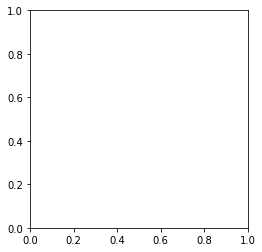

In [183]:
plt.imshow(normbin)

In [168]:
data = np.where(thl > thl.min())
thl[data] = 255.

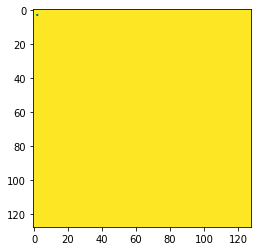

In [169]:
plt.imshow(thl)

In [145]:
imageio.imsave('pred_norm.png', norm)

Lossy conversion from float32 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.


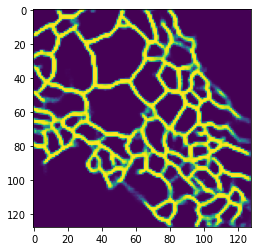

In [146]:
thloc = threshold_local(norm, 3)
plt.imshow(thloc)

In [148]:
thloc.min()
thloc.max()

0.9999817530619982

In [125]:
op_mask = threshold_local(output_probs_np, 9)

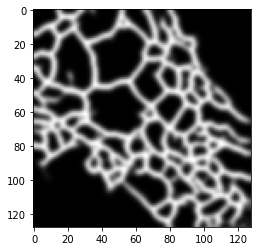

In [126]:
plt.imshow(op_mask, cmap='gray')

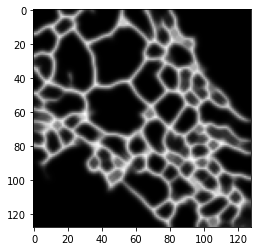

In [128]:
q = erosion(op_mask)
plt.imshow(q, cmap='gray')

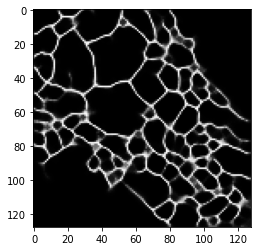

In [129]:
q = erosion(output_probs_np)
plt.imshow(q, cmap='gray')

In [113]:
imageio.imsave('pred_mask.png', output_probs_np)

Lossy conversion from float32 to uint8. Range [0, 1]. Convert image to uint8 prior to saving to suppress this warning.


In [114]:
# Tips to incorporate the topological loss into your own framework
# You have to pretrain your model first and then fine-tune with topoloss, see the rationale part of our paper
# train(pretrain_epoch, topo_epoch):
#    for i in range(0, topo_epoch):
#       if (i<= pretrain_epoch):
#         loss = nn.CrossEntropyLoss();
#       else:
#         loss = nn.CrossEntropyLoss() + lambda * getTopoLoss(lh, gt);

import time
import numpy
import gudhi as gd
from pylab import *
import torch

t0=time.time();

def compute_dgm_force(lh_dgm, gt_dgm, pers_thresh=0, pers_thresh_perfect=0.99, do_return_perfect=False):

    lh_pers = abs(lh_dgm[:, 1] - lh_dgm[:, 0])
    if (gt_dgm.shape[0] == 0):
        gt_pers = None;
        gt_n_holes = 0;
    else:
        gt_pers = gt_dgm[:, 1] - gt_dgm[:, 0]
        gt_n_holes = gt_pers.size  # number of holes in gt
        # gt_n_holes = (gt_pers > 0.03).sum()  # number of holes in gt # ignore flat ones

    if (gt_pers is None or gt_n_holes == 0):
        idx_holes_to_fix = list();
        idx_holes_to_remove = list(set(range(lh_pers.size)))
        idx_holes_perfect = list();
    else:
        # more lh dots than gt dots

        # print (lh_pers.shape)
        # print(lh_pers.size)
        # print (gt_pers.shape)
        # assert lh_pers.size > gt_pers.size
        assert lh_pers.size >= gt_n_holes
        if (lh_pers.size < gt_n_holes):
            gt_n_holes = lh_pers.size

        # check to ensure that all gt dots have persistence 1
        tmp = gt_pers > pers_thresh_perfect

        # assert tmp.sum() == gt_pers.size

        # get "perfect holes" - holes which do not need to be fixed, i.e., find top
        # lh_n_holes_perfect indices
        # check to ensure that at least one dot has persistence 1; it is the hole
        # formed by the padded boundary
        # if no hole is ~1 (ie >.999) then just take all holes with max values
        tmp = lh_pers > pers_thresh_perfect  # old: assert tmp.sum() >= 1
        # print('pers_thresh_perfect', pers_thresh_perfect)
        # print('lh_pers > pers_thresh_perfect', (lh_pers > pers_thresh_perfect).sum())
        # print (type(tmp))
        lh_pers_sorted_indices = np.argsort(lh_pers)[::-1]
        if np.sum(tmp) >= 1:
            # if tmp.sum >= 1:
            # n_holes_to_fix = gt_n_holes - lh_n_holes_perfect
            lh_n_holes_perfect = tmp.sum()
            # idx_holes_perfect = np.argpartition(lh_pers, -lh_n_holes_perfect)[
            #                    -lh_n_holes_perfect:]
            idx_holes_perfect = lh_pers_sorted_indices[:lh_n_holes_perfect];
        else:
            # idx_holes_perfect = np.where(lh_pers == lh_pers.max())[0]
            idx_holes_perfect = list();

        # find top gt_n_holes indices
        # idx_holes_to_fix_or_perfect = np.argpartition(lh_pers, -gt_n_holes)[
        #                              -gt_n_holes:]
        idx_holes_to_fix_or_perfect = lh_pers_sorted_indices[:gt_n_holes];

        # the difference is holes to be fixed to perfect
        idx_holes_to_fix = list(
            set(idx_holes_to_fix_or_perfect) - set(idx_holes_perfect))

        # remaining holes are all to be removed
        # idx_holes_to_remove = list(
        #    set(range(lh_pers.size)) - set(idx_holes_to_fix_or_perfect))
        idx_holes_to_remove = lh_pers_sorted_indices[gt_n_holes:];

    # only select the ones whose persistence is large enough
    # set a threshold to remove meaningless persistence dots
    # TODO values below this are small dents so dont fix them; tune this value?
    pers_thd = pers_thresh
    idx_valid = np.where(lh_pers > pers_thd)[0]
    idx_holes_to_remove = list(
        set(idx_holes_to_remove).intersection(set(idx_valid)))

    force_list = np.zeros(lh_dgm.shape)
    # push each hole-to-fix to (0,1)
    force_list[idx_holes_to_fix, 0] = 0 - lh_dgm[idx_holes_to_fix, 0]
    force_list[idx_holes_to_fix, 1] = 1 - lh_dgm[idx_holes_to_fix, 1]

    # push each hole-to-remove to (0,1)
    force_list[idx_holes_to_remove, 0] = lh_pers[idx_holes_to_remove] / \
                                         math.sqrt(2.0)
    force_list[idx_holes_to_remove, 1] = -lh_pers[idx_holes_to_remove] / \
                                         math.sqrt(2.0)

    if (do_return_perfect):
        return force_list, idx_holes_to_fix, idx_holes_to_remove, idx_holes_perfect

    return force_list, idx_holes_to_fix, idx_holes_to_remove

def getCriticalPoints(likelihood):

    lh = 1 - likelihood
    lh_vector = np.asarray(lh).flatten()

    lh_cubic = gd.CubicalComplex(
        dimensions=[lh.shape[0], lh.shape[1]],
        top_dimensional_cells=lh_vector
    )

    Diag_lh = lh_cubic.persistence(homology_coeff_field=2, min_persistence=0)
    pairs_lh = lh_cubic.cofaces_of_persistence_pairs()

    # if(torch.min(lh_patch) == 1 or torch.max(lh_patch) == 0): continue
    # if(torch.min(gt_patch) == 1 or torch.max(gt_patch) == 0): continue
    
    # return persistence diagram, birth/death critical points
    pd_lh = numpy.array([[lh_vector[pairs_lh[0][0][i][0]], lh_vector[pairs_lh[0][0][i][1]]] for i in range(len(pairs_lh[0][0]))])
    bcp_lh = numpy.array([[pairs_lh[0][0][i][0]//lh.shape[1], pairs_lh[0][0][i][0]%lh.shape[1]] for i in range(len(pairs_lh[0][0]))])
    dcp_lh = numpy.array([[pairs_lh[0][0][i][1]//lh.shape[1], pairs_lh[0][0][i][1]%lh.shape[1]] for i in range(len(pairs_lh[0][0]))])

    return pd_lh, bcp_lh, dcp_lh

def getTopoLoss(likelihood, gt):
    # topo_size = likelihood.shape[0]
    topo_size = 100
    topo_cp_weight_map = np.zeros(likelihood.shape)
    topo_cp_ref_map = np.zeros(likelihood.shape)

    for y in range(0, likelihood.shape[0], topo_size):
        for x in range(0, likelihood.shape[1], topo_size):

            lh_patch = likelihood[y:min(y + topo_size, likelihood.shape[0]),
                         x:min(x + topo_size, likelihood.shape[1])]
            gt_patch = gt[y:min(y + topo_size, gt.shape[0]),
                         x:min(x + topo_size, gt.shape[1])]

            # if(torch.min(lh_patch) == 1 or torch.max(lh_patch) == 0): continue
            # if(torch.min(gt_patch) == 1 or torch.max(gt_patch) == 0): continue
            
            pd_gt, bcp_gt, dcp_gt = getCriticalPoints(gt_patch)
            pd_lh, bcp_lh, dcp_lh = getCriticalPoints(lh_patch)


            force_list, idx_holes_to_fix, idx_holes_to_remove = compute_dgm_force(pd_lh, pd_gt, pers_thresh=0)

            if (len(idx_holes_to_fix) > 0 or len(idx_holes_to_remove) > 0):

                for hole_indx in idx_holes_to_fix:

                    if (int(bcp_lh[hole_indx][0]) >= 0 and int(bcp_lh[hole_indx][0]) < likelihood.shape[0] and int(
                            bcp_lh[hole_indx][1]) >= 0 and int(bcp_lh[hole_indx][1]) < likelihood.shape[1]):
                        topo_cp_weight_map[y + int(bcp_lh[hole_indx][0]), x + int(
                            bcp_lh[hole_indx][1])] = 1  # push birth to 0 i.e. min birth prob or likelihood
                        topo_cp_ref_map[y + int(bcp_lh[hole_indx][0]), x + int(bcp_lh[hole_indx][1])] = 0
                    # if(y+int(dcp_lh[hole_indx][0]) < et_dmap.shape[2] and x+int(dcp_lh[hole_indx][1]) < et_dmap.shape[3]):
                    if (int(dcp_lh[hole_indx][0]) >= 0 and int(dcp_lh[hole_indx][0]) < likelihood.shape[
                        0] and int(dcp_lh[hole_indx][1]) >= 0 and int(dcp_lh[hole_indx][1]) <
                            likelihood.shape[1]):
                        topo_cp_weight_map[y + int(dcp_lh[hole_indx][0]), x + int(
                            dcp_lh[hole_indx][1])] = 1  # push death to 1 i.e. max death prob or likelihood
                        topo_cp_ref_map[y + int(dcp_lh[hole_indx][0]), x + int(dcp_lh[hole_indx][1])] = 1
                for hole_indx in idx_holes_to_remove:

                    if (int(bcp_lh[hole_indx][0]) >= 0 and int(bcp_lh[hole_indx][0]) < likelihood.shape[
                        0] and int(bcp_lh[hole_indx][1]) >= 0 and int(bcp_lh[hole_indx][1]) <
                            likelihood.shape[1]):
                        topo_cp_weight_map[y + int(bcp_lh[hole_indx][0]), x + int(
                            bcp_lh[hole_indx][1])] = 1  # push birth to death  # push to diagonal
                        # if(int(dcp_lh[hole_indx][0]) < likelihood.shape[0] and int(dcp_lh[hole_indx][1]) < likelihood.shape[1]):
                        if (int(dcp_lh[hole_indx][0]) >= 0 and int(dcp_lh[hole_indx][0]) < likelihood.shape[
                            0] and int(dcp_lh[hole_indx][1]) >= 0 and int(dcp_lh[hole_indx][1]) <
                                likelihood.shape[1]):
                            topo_cp_ref_map[y + int(bcp_lh[hole_indx][0]), x + int(bcp_lh[hole_indx][1])] = \
                                lh_patch[int(dcp_lh[hole_indx][0]), int(dcp_lh[hole_indx][1])]
                        else:
                            topo_cp_ref_map[y + int(bcp_lh[hole_indx][0]), x + int(bcp_lh[hole_indx][1])] = 1
                            # if(y+int(dcp_lh[hole_indx][0]) < et_dmap.shape[2] and x+int(dcp_lh[hole_indx][1]) < et_dmap.shape[3]):
                    if (int(dcp_lh[hole_indx][0]) >= 0 and int(dcp_lh[hole_indx][0]) < likelihood.shape[
                        0] and int(dcp_lh[hole_indx][1]) >= 0 and int(dcp_lh[hole_indx][1]) <
                            likelihood.shape[1]):
                        topo_cp_weight_map[y + int(dcp_lh[hole_indx][0]), x + int(
                            dcp_lh[hole_indx][1])] = 1  # push death to birth # push to diagonal
                        # if(int(bcp_lh[hole_indx][0]) < likelihood.shape[0] and int(bcp_lh[hole_indx][1]) < likelihood.shape[1]):
                        if (int(bcp_lh[hole_indx][0]) >= 0 and int(bcp_lh[hole_indx][0]) < likelihood.shape[
                            0] and int(bcp_lh[hole_indx][1]) >= 0 and int(bcp_lh[hole_indx][1]) <
                                likelihood.shape[1]):
                            topo_cp_ref_map[y + int(dcp_lh[hole_indx][0]), x + int(dcp_lh[hole_indx][1])] = \
                                lh_patch[int(bcp_lh[hole_indx][0]), int(bcp_lh[hole_indx][1])]
                        else:
                            topo_cp_ref_map[y + int(dcp_lh[hole_indx][0]), x + int(dcp_lh[hole_indx][1])] = 0

    # topo_cp_weight_map = torch.tensor(topo_cp_weight_map, dtype=torch.float).to(device)
    # topo_cp_ref_map = torch.tensor(topo_cp_ref_map, dtype=torch.float).to(device)
    loss_topo = (((likelihood * topo_cp_weight_map) - topo_cp_ref_map) ** 2).sum()

    return loss_topo


if __name__ == "__main__":
    gt = 1 - imread('/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/rtn/masks/rtn6_er_mean_mask.png')
    lh = 1 - imread('/localhome/asa420/ER-Analysis-scripts/src/nw_graph_analysis/pred_mask.png')

    loss_topo = getTopoLoss(lh, gt)
    print(loss_topo)
    print('time %.3f'%(time.time()-t0));

66.13022807410944
time 0.083
